In [95]:
import pandas as pd

file_path = 'dane/cleaned_data.csv'
df_modeling = pd.read_csv(file_path)
df_modeling.head(20)

,Perfume_ID,Name,Brand,Gender,Rating Value,Rating Count,Clean_Accords,Description,Semantic_Text,url,Main Accords
0,70706,9am,Afnan,for women,3.73,174.0,"citrus, musky, woody, aromatic, warm spicy, la...",9am by Afnan is a fragrance for women. Top not...,Perfume: 9am by Afnan. 9am by Afnan is a fragr...,https://www.fragrantica.com/perfume/Afnan/9am-...,"['citrus', 'musky', 'woody', 'aromatic', 'warm..."
1,78611,9am Dive,Afnan,for women and men,4.29,842.0,"fruity, woody, green, warm spicy, aromatic, ci...",9am Dive by Afnan is a Aromatic Aquatic fragra...,Perfume: 9am Dive by Afnan. 9am Dive by Afnan ...,https://www.fragrantica.com/perfume/Afnan/9am-...,"['fruity', 'woody', 'green', 'warm spicy', 'ar..."
2,78541,9am pour Femme,Afnan,for women,4.00,68.0,"fruity, musky, amber, citrus, powdery, sweet, ...",9am pour Femme by Afnan is a Amber fragrance f...,Perfume: 9am pour Femme by Afnan. 9am pour Fem...,https://www.fragrantica.com/perfume/Afnan/9am-...,"['fruity', 'musky', 'amber', 'citrus', 'powder..."
3,78544,9pm pour Femme,Afnan,for women,3.49,63.0,"woody, aromatic, rose, fruity, powdery, violet...",9pm pour Femme by Afnan is a Amber Floral frag...,Perfume: 9pm pour Femme by Afnan. 9pm pour Fem...,https://www.fragrantica.com/perfume/Afnan/9pm-...,"['woody', 'aromatic', 'rose', 'fruity', 'powde..."
4,36596,Black Oudh,Al Haramain Perfumes,for women and men,4.12,113.0,"woody, powdery, musky, amber, patchouli, vanil...",Black Oudh by Al Haramain Perfumes is a Amber ...,Perfume: Black Oudh by Al Haramain Perfumes. B...,https://www.fragrantica.com/perfume/Al-Haramai...,"['woody', 'powdery', 'musky', 'amber', 'patcho..."
5,19864,Bloom,Al Haramain Perfumes,for women,3.73,55.0,"oud, musky, rose, floral, powdery",Bloom by Al Haramain Perfumes is a Amber Flora...,Perfume: Bloom by Al Haramain Perfumes. Bloom ...,https://www.fragrantica.com/perfume/Al-Haramai...,"['oud', 'musky', 'rose', 'floral', 'powdery']"
6,53174,Dhahab,Al Haramain Perfumes,for women and men,4.41,88.0,"caramel, vanilla, sweet, citrus, powdery, musk...",Dhahab by Al Haramain Perfumes is a fragrance ...,Perfume: Dhahab by Al Haramain Perfumes. Dhaha...,https://www.fragrantica.com/perfume/Al-Haramai...,"['caramel', 'vanilla', 'sweet', 'citrus', 'pow..."
7,19810,Haneen,Al Haramain Perfumes,for women and men,3.94,115.0,"rose, oud, powdery, woody, amber",Haneen by Al Haramain Perfumes is a Amber frag...,Perfume: Haneen by Al Haramain Perfumes. Hanee...,https://www.fragrantica.com/perfume/Al-Haramai...,"['rose', 'oud', 'powdery', 'woody', 'amber']"
8,53250,Khulasat Al Oudh,Al Haramain Perfumes,for men,4.27,168.0,"smoky, leather, amber, woody, animalic, sweet,...",Khulasat Al Oudh by Al Haramain Perfumes is a ...,Perfume: Khulasat Al Oudh by Al Haramain Perfu...,https://www.fragrantica.com/perfume/Al-Haramai...,"['smoky', 'leather', 'amber', 'woody', 'animal..."
9,19953,Musk,Al Haramain Perfumes,for women,4.01,105.0,"musky, floral, powdery, fruity, green, sweet, ...",Musk by Al Haramain Perfumes is a Amber Floral...,Perfume: Musk by Al Haramain Perfumes. Musk by...,https://www.fragrantica.com/perfume/Al-Haramai...,"['musky', 'floral', 'powdery', 'fruity', 'gree..."


In [98]:
import pandas as pd
from sentence_transformers import SentenceTransformer

# 1. Zabezpieczenie przed pustymi wartościami
df_modeling['Clean_Accords'] = df_modeling['Clean_Accords'].fillna("")

# 2. Inżynieria cech: Kolumna Top 3 Akordy (idealna dla UI)
def get_top_3(accords_string):
    accords_list = [a.strip() for a in accords_string.split(',')]
    return ", ".join(accords_list[:3])

df_modeling['Top3_Accords'] = df_modeling['Clean_Accords'].apply(get_top_3)

texts = df_modeling['Top3_Accords'].tolist()

print("Generowanie czystych wektorów zapachowych SBERT...")
model = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2')
embeddings = model.encode(texts, show_progress_bar=True)
df_modeling['Embeddings'] = list(embeddings)

print("✅ Wektoryzacja zakończona sukcesem!")
display(df_modeling[['Name', 'Brand', 'Top3_Accords']].head())

Generowanie czystych wektorów zapachowych SBERT...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Batches:   0%|          | 0/678 [00:00<?, ?it/s]

✅ Wektoryzacja zakończona sukcesem!


,Name,Brand,Top3_Accords
0,9am,Afnan,"citrus, musky, woody"
1,9am Dive,Afnan,"fruity, woody, green"
2,9am pour Femme,Afnan,"fruity, musky, amber"
3,9pm pour Femme,Afnan,"woody, aromatic, rose"
4,Black Oudh,Al Haramain Perfumes,"woody, powdery, musky"


1. Redukcja wymiarów (PCA z 384 do 2 osi X i Y)...


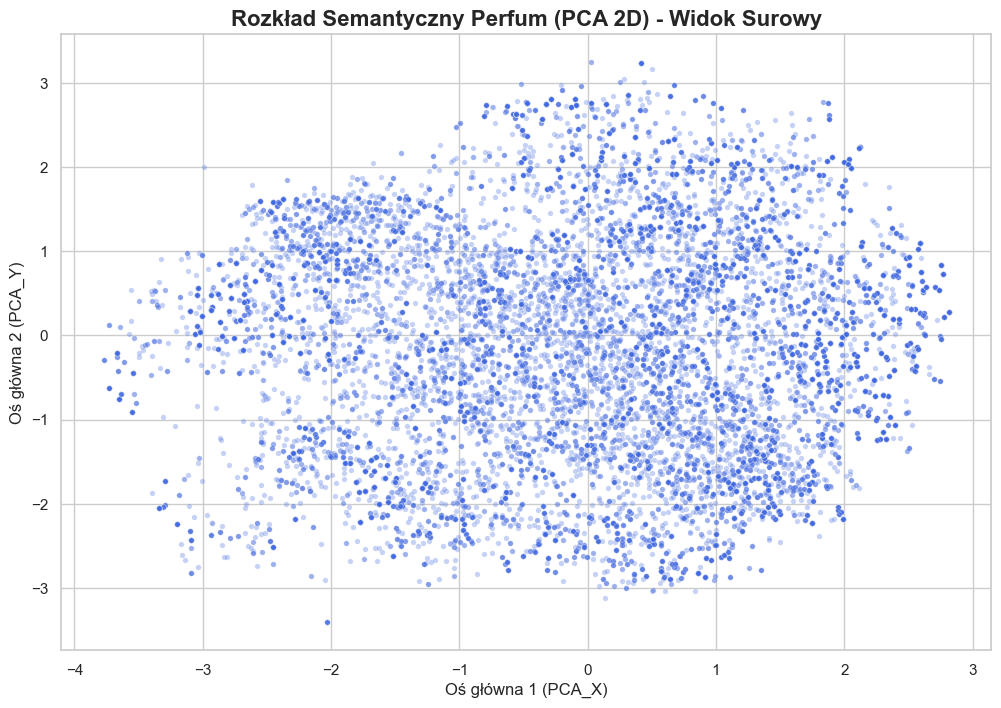

In [99]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
import numpy as np

X_embeddings = np.array(df_modeling['Embeddings'].tolist())

print("1. Redukcja wymiarów (PCA z 384 do 2 osi X i Y)...")
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_embeddings)

df_modeling['PCA_X'] = X_pca[:, 0]
df_modeling['PCA_Y'] = X_pca[:, 1]

plt.figure(figsize=(12, 8))
sns.set_theme(style="whitegrid")

sns.scatterplot(
    x=df_modeling['PCA_X'], 
    y=df_modeling['PCA_Y'], 
    alpha=0.3, 
    s=15, 
    color='royalblue'
)

plt.title('Rozkład Semantyczny Perfum (PCA 2D) - Widok Surowy', fontsize=16, fontweight='bold')
plt.xlabel('Oś główna 1 (PCA_X)', fontsize=12)
plt.ylabel('Oś główna 2 (PCA_Y)', fontsize=12)
plt.show()

Dla K=2 -> Silhouette Score: 0.3680
Dla K=3 -> Silhouette Score: 0.3986
Dla K=4 -> Silhouette Score: 0.3933
Dla K=5 -> Silhouette Score: 0.3886
Dla K=6 -> Silhouette Score: 0.3621
Dla K=7 -> Silhouette Score: 0.4143
Dla K=8 -> Silhouette Score: 0.3832
Dla K=9 -> Silhouette Score: 0.3838
Dla K=10 -> Silhouette Score: 0.3894


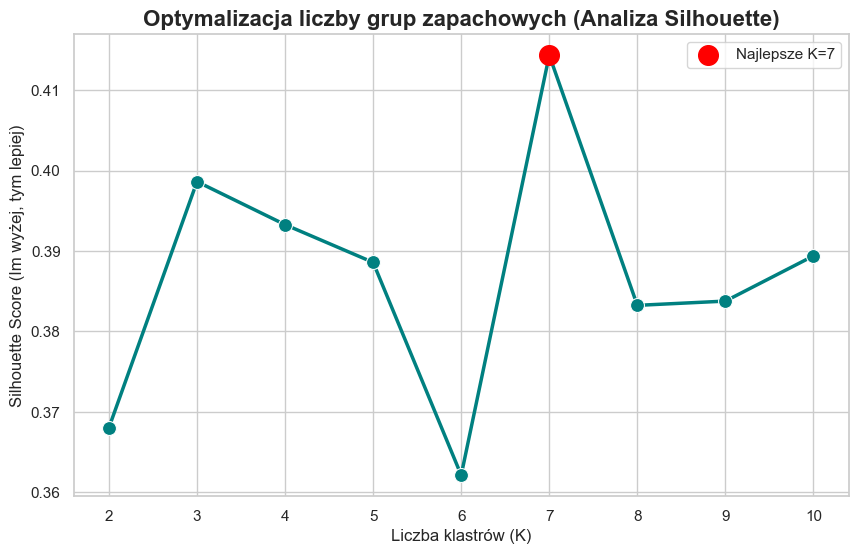


Matematycznie najlepszy podział to K=7 (Wynik: 0.4143)


In [100]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns

k_values = range(2, 11)
silhouette_scores = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init="auto")
    
    cluster_labels = kmeans.fit_predict(df_modeling[['PCA_X', 'PCA_Y']])
    
    score = silhouette_score(df_modeling[['PCA_X', 'PCA_Y']], cluster_labels)
    
    silhouette_scores.append(score)
    print(f"Dla K={k} -> Silhouette Score: {score:.4f}")

plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

sns.lineplot(x=k_values, y=silhouette_scores, marker='o', markersize=10, color='teal', linewidth=2.5)

best_k_index = silhouette_scores.index(max(silhouette_scores))
best_k = k_values[best_k_index]
best_score = silhouette_scores[best_k_index]
plt.scatter(best_k, best_score, color='red', s=200, zorder=5, label=f'Najlepsze K={best_k}')

plt.title('Optymalizacja liczby grup zapachowych (Analiza Silhouette)', fontsize=16, fontweight='bold')
plt.xlabel('Liczba klastrów (K)', fontsize=12)
plt.ylabel('Silhouette Score (Im wyżej, tym lepiej)', fontsize=12)
plt.xticks(k_values)
plt.legend()
plt.show()

print(f"\nMatematycznie najlepszy podział to K={best_k} (Wynik: {best_score:.4f})")

Liczba klastrów (grup): 7
Wynik Silhouette Score: 0.4143


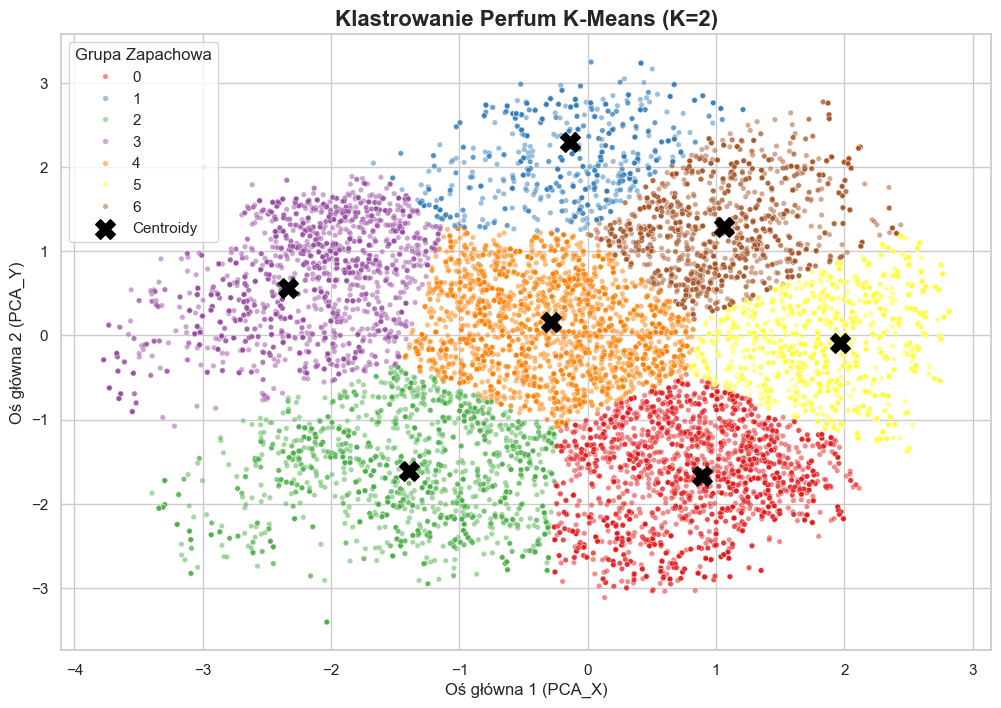

In [101]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns

num_clusters = 2

kmeans = KMeans(n_clusters=best_k, random_state=42, n_init="auto")

df_modeling['Cluster_ID'] = kmeans.fit_predict(df_modeling[['PCA_X', 'PCA_Y']])

sil_score = silhouette_score(df_modeling[['PCA_X', 'PCA_Y']], df_modeling['Cluster_ID'])

print(f"Liczba klastrów (grup): {best_k}")
print(f"Wynik Silhouette Score: {sil_score:.4f}")

plt.figure(figsize=(12, 8))
sns.set_theme(style="whitegrid")

scatter = sns.scatterplot(
    x=df_modeling['PCA_X'], 
    y=df_modeling['PCA_Y'], 
    hue=df_modeling['Cluster_ID'], 
    palette='Set1', 
    alpha=0.5, 
    s=15
)

centroids = kmeans.cluster_centers_
plt.scatter(centroids[:, 0], centroids[:, 1], c='black', s=200, marker='X', label='Centroidy')

plt.title(f'Klastrowanie Perfum K-Means (K={num_clusters})', fontsize=16, fontweight='bold')
plt.xlabel('Oś główna 1 (PCA_X)', fontsize=12)
plt.ylabel('Oś główna 2 (PCA_Y)', fontsize=12)
plt.legend(title='Grupa Zapachowa')
plt.show()

In [104]:
import pandas as pd
from collections import Counter

print("--- PROFILOWANIE KLASTRÓW ZAPACHOWYCH ---")

unique_clusters = sorted(df_modeling['Cluster_ID'].unique())

for cluster_num in unique_clusters:
    cluster_data = df_modeling[df_modeling['Cluster_ID'] == cluster_num]['Clean_Accords']
    
    all_accords = []
    for accords_string in cluster_data.dropna():
        accords = [accord.strip().lower() for accord in accords_string.split(',')]
        all_accords.extend(accords)
        
    accord_counts = Counter(all_accords)
    
    top_accords = accord_counts.most_common(5)
    
    print(f"\nKLASTER {cluster_num} (Liczba perfum: {len(cluster_data)})")
    
    tags = [f"{accord} ({count}x)" for accord, count in top_accords]
    print("Dominujące akordy:", ", ".join(tags))

--- PROFILOWANIE KLASTRÓW ZAPACHOWYCH ---

KLASTER 0 (Liczba perfum: 3673)
Dominujące akordy: floral (2679x), woody (2315x), white floral (2237x), powdery (2200x), sweet (1760x)

KLASTER 1 (Liczba perfum: 1707)
Dominujące akordy: citrus (1493x), aromatic (1283x), fresh spicy (1224x), woody (1184x), warm spicy (954x)

KLASTER 2 (Liczba perfum: 2638)
Dominujące akordy: woody (2320x), powdery (1486x), aromatic (1354x), amber (1267x), warm spicy (1247x)

KLASTER 3 (Liczba perfum: 3599)
Dominujące akordy: woody (3002x), warm spicy (2899x), aromatic (2406x), fresh spicy (2176x), amber (1922x)

KLASTER 4 (Liczba perfum: 3479)
Dominujące akordy: woody (2226x), powdery (2167x), sweet (2000x), vanilla (1708x), warm spicy (1519x)

KLASTER 5 (Liczba perfum: 3323)
Dominujące akordy: citrus (2379x), floral (2345x), sweet (2242x), fruity (2199x), white floral (2046x)

KLASTER 6 (Liczba perfum: 3273)
Dominujące akordy: citrus (2314x), sweet (2283x), fruity (2027x), woody (1766x), powdery (1586x)


In [ ]:
# zaimplementować TfidfVectorizer jako filtr wagowy dla akordów